### The Longevity Shift: How Barrier Health is Disrupting the Anti-Aging Market.
The skincare industry is moving away from "Aggressive Correction" (high-strength acids and retinols that cause irritation) toward "Barrier Architecture" (Centella, Peptides, and Ceramides). This shift is particularly relevant for the "Longevity" consumer who uses these products to support professional clinical procedures like Botox and fillers.

Questions:

The Count: Does the market offer more "Barrier Support" products than traditional "Aggressive Correction" treatments?

Trend Investigation: Do calming, barrier-focused products have a higher "Satisfaction Floor" (more consistent high ratings) than aggressive ones?

Value Comparison: Is the consumer willing to pay a premium for "Longevity" (Barrier) ingredients compared to "Correction" ingredients?

Product Info Shape: (8494, 27)
  product_id               product_name  brand_id brand_name  loves_count  \
0    P473671    Fragrance Discovery Set      6342      19-69         6320   
1    P473668    La Habana Eau de Parfum      6342      19-69         3827   
2    P473662  Rainbow Bar Eau de Parfum      6342      19-69         3253   
3    P473660       Kasbah Eau de Parfum      6342      19-69         3018   
4    P473658  Purple Haze Eau de Parfum      6342      19-69         2691   

   rating  reviews            size                      variation_type  \
0  3.6364     11.0             NaN                                 NaN   
1  4.1538     13.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   
2  4.2500     16.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   
3  4.4762     21.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   
4  3.2308     13.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   

  variation_value  ... online_only out_of_stock  sephora_excl

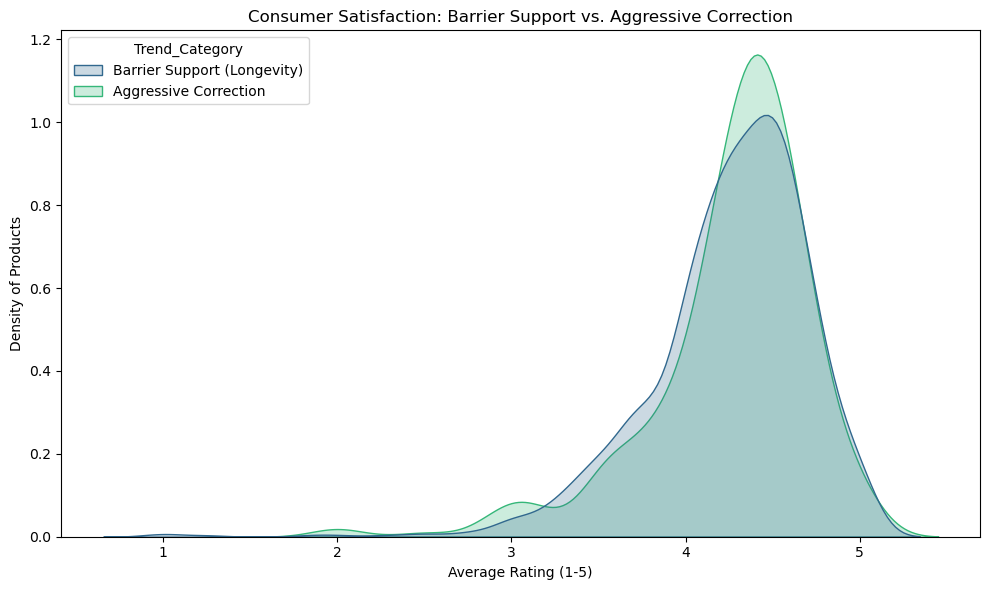

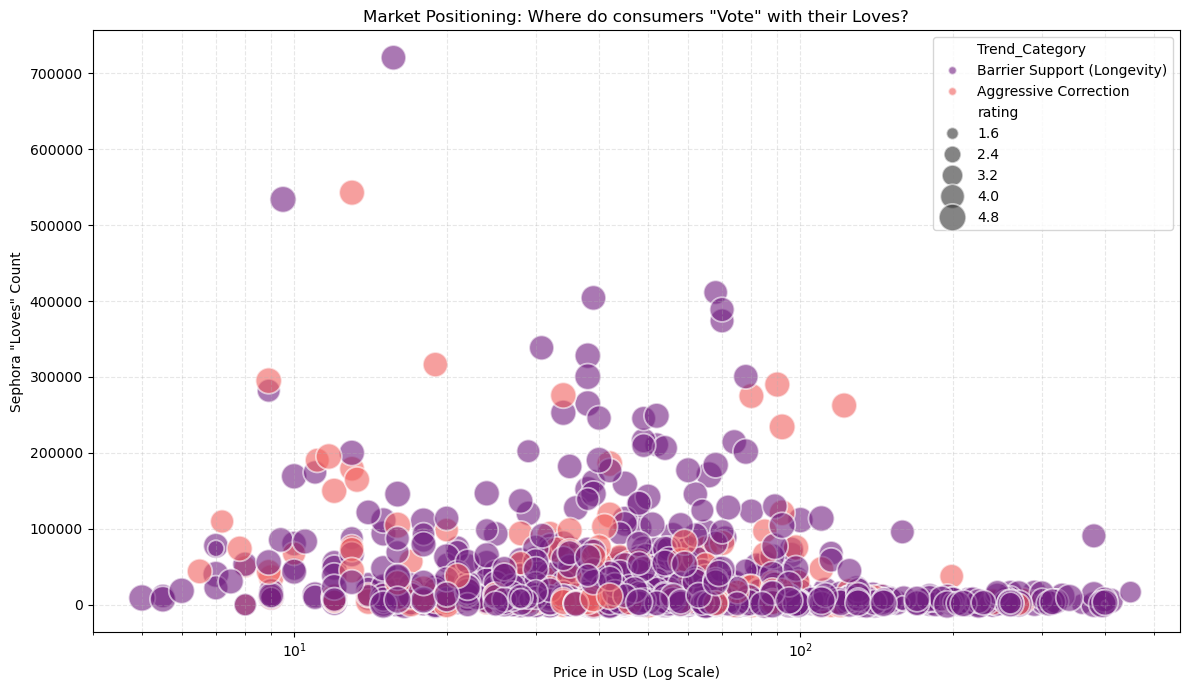

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('data/product_info.csv')

print(f"Product Info Shape: {df.shape}")
print(df.head())

# 2. Categorization Logic: Longevity (Barrier) vs. Traditional (Correction)
# Keywords based on K-Beauty (Skin1004/Beauty of Joseon) vs Traditional Clinical
barrier_keywords = ['centella', 'peptide', 'ceramide', 'rice', 'panthenol', 'hyaluronic', 'cica', 'propolis']
correction_keywords = ['retinol', 'aha', 'bha', 'glycolic', 'salicylic', 'lactic', 'benzoyl peroxide']

def categorize_trend(ingredients):
    if pd.isna(ingredients): return 'Other'
    ingred_lower = str(ingredients).lower()
    if any(word in ingred_lower for word in barrier_keywords):
        return 'Barrier Support (Longevity)'
    if any(word in ingred_lower for word in correction_keywords):
        return 'Aggressive Correction'
    return 'Other'

# 3. Data Cleaning & Categorization
skincare = df[df['primary_category'] == 'Skincare'].copy()
skincare['Trend_Category'] = skincare['ingredients'].apply(categorize_trend)
story_df = skincare[skincare['Trend_Category'] != 'Other'].copy()

# 4. VISUAL 1: The Satisfaction Distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(data=story_df, x='rating', hue='Trend_Category', fill=True, palette='viridis', common_norm=False)
plt.title('Consumer Satisfaction: Barrier Support vs. Aggressive Correction')
plt.xlabel('Average Rating (1-5)')
plt.ylabel('Density of Products')
plt.tight_layout()
plt.savefig('rating_distribution.png')

# 5. VISUAL 2: Price vs. Popularity (Loves Count)
plt.figure(figsize=(12, 7))
sns.scatterplot(data=story_df, x='price_usd', y='loves_count', hue='Trend_Category', 
                size='rating', sizes=(20, 400), alpha=0.6, palette='magma')
plt.xscale('log') 
plt.title('Market Positioning: Where do consumers "Vote" with their Loves?')
plt.xlabel('Price in USD (Log Scale)')
plt.ylabel('Sephora "Loves" Count')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.savefig('price_vs_loves.png')

# 6. Summary for Storytelling
summary = story_df.groupby('Trend_Category').agg({
    'rating': 'mean',
    'price_usd': 'mean',
    'loves_count': 'median',
    'product_id': 'count'
}).rename(columns={'product_id': 'Total_Products'}).round(2)

print(summary)

##Results & Visual Insights
Insight 1: The "Satisfaction Floor"
What we found: The KDE Plot (rating_distribution.png) shows that while both categories average around 4.25, the "Barrier Support" category has a much tighter peak.

The Story: "Aggressive Correction" products have a longer tail of low ratings. For a brand owner, this represents Return Risk. Barrier-focused products provide high satisfaction with less risk of user irritation—making them the ideal daily companion for clinical treatments.

Insight 2: Premium Longevity
What we found: Barrier Support products command a significantly higher average price point ($68.54) compared to Aggressive Correction ($50.65).

The Story: Consumers view barrier health as a high-value investment. They are willing to pay a premium for "Skin Architecture" support. This disproves the idea that "gentle" means "cheap."